<a href="https://colab.research.google.com/github/KingTechnician/shared-truth/blob/main/shared_truth_section42_recheck.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# §4.2 recheck: full-injection collapse and the Fisher ratio J

Recomputes every number in §4.2 of the submitted paper from the saved sweeps, and checks the
Procrustes collapse claims in §4.2 and §5. CPU only, about a minute; downloads ~60 MB of JSON and
uploads nothing.

| part | does |
|---|---|
| **1. Data** | pulls the 22 published runs listed in `procrustes_n21_summary.json` and finds the duplicated trajectory |
| **2. Per trajectory** | AUROC and τ₀ accuracy at α=0 and α=1, and J on the probe-score distributions |
| **3. Against the paper** | every §4.2 number, for the 21 unique trajectories and for all 22 rows, next to the value the paper prints |
| **4. Median curves** | median accuracy, AUROC and J at each α (the plateau and the inflection) |
| **5. Procrustes at α=1** | checks "Procrustes collapses at α=1 on all 21" (§4.2) and "on 20 of 21" (§5) |

**J.** The paper defines J = (μ_T − μ_F)² / (σ_T² + σ_F²). With scalar means it is computed on the
target probe's **scores** (P(true)) for true and false statements, not on activations; that is the
reading used here. It is a different quantity from the layer-selection J of Appendix A.1, which is
computed on activations. σ² is the population variance (`ddof=0`); with ~800 items per class `ddof=1`
moves J by about 0.1%.

**The "∼14×".** 3.46 / 0.30 is 11.5, so the paper's ∼14× cannot be the ratio of the two medians. Part 3
reports both the ratio of medians and the median of per-pair ratios J(α=0)/J(α=1); the IQR the paper gives,
[6.5, 35.9], is an IQR of per-pair ratios.

In [9]:
# --- setup ------------------------------------------------------------------
# Self-contained: needs only huggingface_hub, numpy, pandas and scipy (all preinstalled on Colab).
import os, json
from pathlib import Path

import numpy as np
import pandas as pd
from huggingface_hub import hf_hub_download, snapshot_download

try:
    from google.colab import userdata
    os.environ.setdefault("HF_TOKEN", userdata.get("HF_TOKEN"))
except Exception:
    pass   # not in Colab, or no secret set

RESULTS_REPO = "KingTechnician/shared-truth-results"
REVISION     = None          # set to "camera-ready" once that tag exists
LOCAL_ROOT   = os.environ.get("SHARED_TRUTH_RESULTS_DIR")   # an existing snapshot skips the download
OUT_PATH     = Path("/content/sec42_recheck.json") if Path("/content").exists() else Path("sec42_recheck.json")

TIE_PP       = 0.5           # the paper's tie band for Procrustes vs trained (pp)
PLATEAU_MAX  = 0.7           # §4.2: "near-flat plateau through α ∈ [0, 0.7]"

## 1. Data

The population is the 22 `pair_id`s recorded in the published `procrustes_n21_summary.json`, the same
pinned list the Procrustes notebook uses, never a directory glob: the sweep folder also holds the
multi-seed, baseline and full-test-set runs, which use different evals. The duplicate is found by
content (identical models, layers and scores), not by name.

In [2]:
token = os.environ.get("HF_TOKEN")
if LOCAL_ROOT:
    ROOT = Path(LOCAL_ROOT)
else:
    summary_path = hf_hub_download(RESULTS_REPO, "procrustes_n21_summary.json", repo_type="dataset",
                                   revision=REVISION, token=token)
    pids = [r["pair_id"] for r in json.load(open(summary_path))["rows"]]
    ROOT = Path(snapshot_download(
        RESULTS_REPO, repo_type="dataset", revision=REVISION, token=token,
        allow_patterns=["procrustes_n21_summary.json"]
                       + [f"sweep-results/{p}/{f}" for p in pids
                          for f in ("sweep_results.json", "procrustes_sweep.json")]))

SWEEPS = ROOT / "sweep-results"
reference = json.load(open(ROOT / "procrustes_n21_summary.json"))
POPULATION = sorted(r["pair_id"] for r in reference["rows"])
assert len(POPULATION) == 22, f"expected the 22 published runs, found {len(POPULATION)}"

runs = {p: json.load(open(SWEEPS / p / "sweep_results.json")) for p in POPULATION}
procs = {p: json.load(open(SWEEPS / p / "procrustes_sweep.json")) for p in POPULATION}


def by_alpha(sweep):
    return {round(float(r["alpha"]), 1): r for r in sweep}


def signature(p):
    r = runs[p]
    return (r["source_model"], r["source_layer"], r["target_model"], r["target_layer"],
            tuple(tuple(np.round(x["true_scores"], 9)) for x in r["alpha_sweep"]))


seen, DUPLICATES = {}, {}
for p in POPULATION:
    k = signature(p)
    if k in seen:
        DUPLICATES[p] = seen[k]
    else:
        seen[k] = p
UNIQUE = [p for p in POPULATION if p not in DUPLICATES]

print(f"{len(POPULATION)} published runs, {len(UNIQUE)} unique")
for d, c in DUPLICATES.items():
    print(f"  duplicate: {d}\n   same as:  {c}")
assert len(UNIQUE) == 21, "expected exactly one duplicated trajectory"

procrustes_n21_summary.json:   0%|          | 0.00/11.3k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 45 files:   0%|          | 0/45 [00:00<?, ?it/s]

22 published runs, 21 unique
  duplicate: llama3_2-3b-instruct_l12_to_qwen2_5-1_5b-instruct_l12__transfer_truth
   same as:  llama3_2-3b-instruct_l12_to_qwen2_5-1_5b-instruct_l12__transfer_rsa


## 2. Per trajectory

One row per published run. `acc` is accuracy at the probe's own threshold τ₀ = 0.5, as a fraction.
`J_ratio` = J(α=0) / J(α=1).

In [3]:
def fisher_j(row, ddof=0):
    t = np.asarray(row["true_scores"], dtype=float)
    f = np.asarray(row["false_scores"], dtype=float)
    return float((t.mean() - f.mean()) ** 2 / (t.var(ddof=ddof) + f.var(ddof=ddof)))


rows = []
for p in POPULATION:
    s = by_alpha(runs[p]["alpha_sweep"])
    a0, a1 = s[0.0], s[1.0]
    rows.append({
        "pair_id": p,
        "label": runs[p].get("display_label", p),
        "duplicate": p in DUPLICATES,
        "n_true": len(a0["true_scores"]), "n_false": len(a0["false_scores"]),
        "auroc_a0": a0["auroc"], "auroc_a1": a1["auroc"],
        "auroc_plateau_min": min(s[a]["auroc"] for a in s if a <= PLATEAU_MAX + 1e-9),
        "acc_a0": a0["accuracy"], "acc_a1": a1["accuracy"],
        "J_a0": fisher_j(a0), "J_a1": fisher_j(a1),
        "J_a0_ddof1": fisher_j(a0, 1), "J_a1_ddof1": fisher_j(a1, 1),
    })

per = pd.DataFrame(rows).set_index("pair_id")
per["J_ratio"] = per["J_a0"] / per["J_a1"]

sizes = per[["n_true", "n_false"]].drop_duplicates()
print("eval sizes (true, false):", sizes.values.tolist(), " total", int(sizes.sum(axis=1).iloc[0]))
pd.set_option("display.width", 200)
per.drop(columns=["J_a0_ddof1", "J_a1_ddof1", "n_true", "n_false"]).sort_values("J_ratio").round(3)

eval sizes (true, false): [[792, 807]]  total 1599


,label,duplicate,auroc_a0,auroc_a1,auroc_plateau_min,acc_a0,acc_a1,J_a0,J_a1,J_ratio
pair_id,,,,,,,,,,
llama3_2-3b-instruct_l12_to_qwen2_5-1_5b-instruct_l12__transfer_truth,Llama-3.2-3B (L12) → Qwen2.5-1.5B (L12),True,0.691,0.741,0.691,0.585,0.495,0.182,0.324,0.563
llama3_2-3b-instruct_l12_to_qwen2_5-1_5b-instruct_l12__transfer_rsa,Llama-3.2-3B (L12) → Qwen2.5-1.5B (L12),False,0.691,0.741,0.691,0.585,0.495,0.182,0.324,0.563
llama3-8b-instruct_l12_to_gemma2-2b-instruct_l13__transfer_truth,Llama-3-8B (L12) → Gemma-2-2B (L13),False,0.969,0.843,0.969,0.873,0.555,4.031,0.981,4.111
qwen2_5-1_5b-instruct_l17_to_gemma2-2b-instruct_l13__truth,Qwen2.5-1.5B (L17) → Gemma-2-2B (L13),False,0.969,0.845,0.969,0.873,0.574,4.031,0.941,4.281
qwen2_5-1_5b-instruct_l17_to_llama3_2-3b-instruct_l12__truth,Qwen2.5-1.5B (L17) → Llama-3.2-3B (L12),False,0.929,0.716,0.929,0.770,0.617,1.552,0.339,4.579
gemma2-2b-instruct_l13_to_llama3_2-3b-instruct_l12__truth,Gemma-2-2B (L13) → Llama-3.2-3B (L12),False,0.929,0.708,0.929,0.770,0.575,1.552,0.300,5.181
llama3_2-3b-instruct_l12_to_qwen2_5-1_5b-instruct_l17__truth,Llama-3.2-3B (L12) → Qwen2.5-1.5B (L17),False,0.944,0.850,0.944,0.876,0.495,3.404,0.524,6.502
llama3-8b-instruct_l14_to_gemma2-2b-instruct_l14__transfer_rsa,Llama-3-8B (L14) → Gemma-2-2B (L14),False,0.972,0.840,0.970,0.899,0.680,5.377,0.782,6.880
llama3_2-3b-instruct_l13_to_gemma2-2b-instruct_l14__transfer_rsa,Llama-3.2-3B (L13) → Gemma-2-2B (L14),False,0.972,0.836,0.968,0.899,0.777,5.377,0.756,7.113


## 3. Against the paper

Each §4.2 number for the 21 unique trajectories and for all 22 rows, next to the value the paper prints.
A row matches when the recomputed value rounds to the printed one at the printed precision.
`which` says which population reproduces the paper; if only the 22-row column matches, that number
counted the duplicated trajectory twice, although Appendix A.6 says the aggregates are deduplicated.

In [4]:
def q(x, pct):
    return float(np.percentile(np.asarray(x, dtype=float), pct))


def aggregates(df):
    r = df["J_ratio"]
    return {
        "median τ0 accuracy at α=1":          float(df["acc_a1"].median()),
        "median AUROC at α=0":                float(df["auroc_a0"].median()),
        "median AUROC at α=1":                float(df["auroc_a1"].median()),
        "AUROC α=1, IQR low":                 q(df["auroc_a1"], 25),
        "AUROC α=1, IQR high":                q(df["auroc_a1"], 75),
        "AUROC α=1, min":                     float(df["auroc_a1"].min()),
        "AUROC α=1, max":                     float(df["auroc_a1"].max()),
        "trajectories with AUROC α=1 > 0.7":  int((df["auroc_a1"] > 0.7).sum()),
        "trajectories with AUROC α=1 > 0.9":  int((df["auroc_a1"] > 0.9).sum()),
        "median J at α=0":                    float(df["J_a0"].median()),
        "median J at α=1":                    float(df["J_a1"].median()),
        "ratio of medians J(α=0)/J(α=1)":     float(df["J_a0"].median() / df["J_a1"].median()),
        "median per-pair J ratio":            float(r.median()),
        "per-pair J ratio, IQR low":          q(r, 25),
        "per-pair J ratio, IQR high":         q(r, 75),
    }


# (value printed in the paper, decimals it is printed to); None = no printed value
PAPER = {
    "median τ0 accuracy at α=1":          (0.51, 2),
    "median AUROC at α=0":                (0.97, 2),   # "near-ceiling sweep value of ∼0.97"
    "median AUROC at α=1":                (0.72, 2),
    "AUROC α=1, IQR low":                 (0.65, 2),
    "AUROC α=1, IQR high":                (0.79, 2),
    "AUROC α=1, min":                     (0.53, 2),
    "AUROC α=1, max":                     (0.85, 2),
    "trajectories with AUROC α=1 > 0.7":  (12, 0),
    "trajectories with AUROC α=1 > 0.9":  (0, 0),
    "median J at α=0":                    (3.46, 2),
    "median J at α=1":                    (0.30, 2),
    "ratio of medians J(α=0)/J(α=1)":     (14, 0),     # "collapses by ∼14×"
    "median per-pair J ratio":            (14, 0),     # the other reading of "∼14×"
    "per-pair J ratio, IQR low":          (6.5, 1),
    "per-pair J ratio, IQR high":         (35.9, 1),
}

agg21 = aggregates(per.loc[UNIQUE])
agg22 = aggregates(per)


def matches(v, paper):
    want, dec = paper
    return round(v, dec) == round(want, dec)


table = []
for k, paper in PAPER.items():
    m21, m22 = matches(agg21[k], paper), matches(agg22[k], paper)
    which = "both" if m21 and m22 else "n=21" if m21 else "n=22 only" if m22 else "neither"
    table.append({"quantity": k, "paper": paper[0], "n=21": agg21[k], "n=22": agg22[k], "which": which})
check = pd.DataFrame(table).set_index("quantity")
print("J uses ddof=0. With ddof=1 the medians are "
      f"{per.loc[UNIQUE, 'J_a0_ddof1'].median():.3f} (α=0) and {per.loc[UNIQUE, 'J_a1_ddof1'].median():.3f} (α=1), n=21.\n")
check.round(3)

J uses ddof=0. With ddof=1 the medians are 3.463 (α=0) and 0.299 (α=1), n=21.



,paper,n=21,n=22,which
quantity,,,,
median τ0 accuracy at α=1,0.51,0.511,0.508,both
median AUROC at α=0,0.97,0.969,0.967,both
median AUROC at α=1,0.72,0.716,0.720,both
"AUROC α=1, IQR low",0.65,0.646,0.650,both
"AUROC α=1, IQR high",0.79,0.789,0.778,n=21
"AUROC α=1, min",0.53,0.532,0.532,both
"AUROC α=1, max",0.85,0.850,0.850,both
trajectories with AUROC α=1 > 0.7,12.00,12.000,13.000,n=21
trajectories with AUROC α=1 > 0.9,0.00,0.000,0.000,both


In [5]:
off = check[check["which"].isin(["neither", "n=22 only"])]
if off.empty:
    print("✓ every §4.2 number reproduces on the 21 unique trajectories")
else:
    print(f"{len(off)} of {len(check)} printed numbers do not reproduce on the 21 unique trajectories:\n")
    for k, r in off.iterrows():
        note = "  (matches only when the duplicate is counted twice)" if r["which"] == "n=22 only" else ""
        print(f"  {k:<36} paper {r['paper']:<6}  n=21 {r['n=21']:.3f}   n=22 {r['n=22']:.3f}{note}")
    print("\nThe two '∼14×' rows are alternative readings of one claim; one of them failing is expected.")

2 of 15 printed numbers do not reproduce on the 21 unique trajectories:

  median J at α=0                      paper 3.46    n=21 3.467   n=22 3.436
  ratio of medians J(α=0)/J(α=1)       paper 14.0    n=21 11.571   n=22 11.248

The two '∼14×' rows are alternative readings of one claim; one of them failing is expected.


## 4. Median curves over α (21 unique trajectories)

Supports the plateau (AUROC flat through α = 0.7), the inflection (0.8–0.9) and the collapse at α = 1.

In [6]:
alphas = sorted(by_alpha(runs[UNIQUE[0]]["alpha_sweep"]))
curve = []
for a in alphas:
    acc = [by_alpha(runs[p]["alpha_sweep"])[a]["accuracy"] for p in UNIQUE]
    auc = [by_alpha(runs[p]["alpha_sweep"])[a]["auroc"] for p in UNIQUE]
    jj  = [fisher_j(by_alpha(runs[p]["alpha_sweep"])[a]) for p in UNIQUE]
    curve.append({"alpha": a, "median_acc": np.median(acc), "median_auroc": np.median(auc),
                  "auroc_IQR": f"[{q(auc, 25):.3f}, {q(auc, 75):.3f}]", "median_J": np.median(jj)})
curve = pd.DataFrame(curve).set_index("alpha")
plateau_drop = curve.loc[0.0, "median_auroc"] - curve.loc[:PLATEAU_MAX + 1e-9, "median_auroc"].min()
print(f"largest drop of the median AUROC below its α=0 value within α ≤ {PLATEAU_MAX}: {plateau_drop:.3f}")
curve.round(3)

largest drop of the median AUROC below its α=0 value within α ≤ 0.7: 0.001


,median_acc,median_auroc,auroc_IQR,median_J
alpha,,,,
0.0,0.841,0.969,"[0.944, 0.971]",3.467
0.1,0.838,0.969,"[0.945, 0.971]",3.632
0.2,0.855,0.969,"[0.947, 0.971]",3.790
0.3,0.856,0.969,"[0.949, 0.971]",3.875
0.4,0.863,0.969,"[0.950, 0.972]",3.754
0.5,0.866,0.969,"[0.951, 0.972]",3.689
0.6,0.862,0.969,"[0.953, 0.971]",3.510
0.7,0.856,0.968,"[0.956, 0.970]",3.183
0.8,0.817,0.962,"[0.956, 0.966]",2.728


## 5. Procrustes at α = 1

Collapse is checked three ways:

- **Accuracy:**
- **AUROC**
- **less than trained:**

In [7]:
prow = []
for p in UNIQUE:
    r = procs[p]
    ceil = r["ceiling"]["accuracy"]
    pr = by_alpha(r["procrustes_sweep"]); tr = by_alpha(r["trained_sweep"])
    prow.append({
        "pair_id": p, "label": r.get("display_label", p),
        "ceiling_pct": 100 * ceil,
        "proc_acc_a1_vs_ceiling_pp": 100 * (pr[1.0]["accuracy"] - ceil),
        "trained_acc_a1_vs_ceiling_pp": 100 * (tr[1.0]["accuracy"] - ceil),
        "proc_auroc_a0": pr[0.0]["auroc"], "proc_auroc_a1": pr[1.0]["auroc"],
        "trained_auroc_a1": tr[1.0]["auroc"],
    })
pdf = pd.DataFrame(prow).set_index("pair_id")
pdf["collapsed_accuracy"] = pdf["proc_acc_a1_vs_ceiling_pp"] < -TIE_PP
pdf["collapsed_auroc"] = (pdf["proc_auroc_a0"] - pdf["proc_auroc_a1"]) > 0.05
pdf["degrades_less_than_trained"] = pdf["proc_acc_a1_vs_ceiling_pp"] > pdf["trained_acc_a1_vs_ceiling_pp"] + TIE_PP

n = len(pdf)
print(f"Procrustes collapses on accuracy (> {TIE_PP} pp below ceiling at α=1): {int(pdf.collapsed_accuracy.sum())}/{n}")
print(f"Procrustes collapses on AUROC (drop > 0.05 from α=0):              {int(pdf.collapsed_auroc.sum())}/{n}")
print(f"Procrustes degrades less than trained at α=1:                      {int(pdf.degrades_less_than_trained.sum())}/{n}")
print(f"median AUROC at α=1: Procrustes {pdf.proc_auroc_a1.median():.3f}   trained {pdf.trained_auroc_a1.median():.3f}")
not_collapsed = pdf[~pdf.collapsed_accuracy]
if len(not_collapsed):
    print(f"\nnot collapsed on accuracy at α=1 ({len(not_collapsed)}):")
    for _, r in not_collapsed.iterrows():
        print(f"  {r['label']:<46} {r['proc_acc_a1_vs_ceiling_pp']:+6.2f} pp vs ceiling   "
              f"AUROC {r['proc_auroc_a0']:.3f} → {r['proc_auroc_a1']:.3f}")
pdf.drop(columns=["label"]).round(3)

Procrustes collapses on accuracy (> 0.5 pp below ceiling at α=1): 17/21
Procrustes collapses on AUROC (drop > 0.05 from α=0):              9/21
Procrustes degrades less than trained at α=1:                      20/21
median AUROC at α=1: Procrustes 0.910   trained 0.716

not collapsed on accuracy at α=1 (4):
  Gemma-2-2B (L13) → Llama-3.2-3B (L12)          +11.38 pp vs ceiling   AUROC 0.929 → 0.942
  Llama-3-8B (L12) → Mistral-7B (L13)             +0.13 pp vs ceiling   AUROC 0.971 → 0.954
  Llama-3-8B (L14) → Mistral-7B (L14)             +6.44 pp vs ceiling   AUROC 0.966 → 0.942
  Llama-3.2-3B (L12) → Qwen2.5-1.5B (L12)        +10.38 pp vs ceiling   AUROC 0.691 → 0.843


,ceiling_pct,proc_acc_a1_vs_ceiling_pp,trained_acc_a1_vs_ceiling_pp,proc_auroc_a0,proc_auroc_a1,trained_auroc_a1,collapsed_accuracy,collapsed_auroc,degrades_less_than_trained
pair_id,,,,,,,,,
gemma2-2b-instruct_l13_to_llama3_2-3b-instruct_l12__truth,77.048,11.382,-19.575,0.929,0.942,0.708,False,False,True
gemma2-2b-instruct_l13_to_qwen2_5-1_5b-instruct_l17__truth,87.555,-9.881,-38.024,0.944,0.904,0.727,True,False,True
llama3-8b-instruct_l12_to_gemma2-2b-instruct_l13__transfer_truth,87.305,-3.064,-31.832,0.969,0.920,0.843,True,False,True
llama3-8b-instruct_l12_to_mistral-7b-instruct_l13__truth,82.802,0.125,-32.270,0.971,0.954,0.609,False,False,True
llama3-8b-instruct_l14_to_gemma2-2b-instruct_l14__transfer_rsa,89.869,-1.689,-21.826,0.972,0.924,0.840,True,False,True
llama3-8b-instruct_l14_to_mistral-7b-instruct_l14__transfer_rsa,82.802,6.442,-32.395,0.966,0.942,0.618,False,False,True
llama3_2-3b-instruct_l12_to_gemma2-2b-instruct_l13__truth,87.305,-10.757,-28.143,0.969,0.923,0.789,True,False,True
llama3_2-3b-instruct_l12_to_mistral-7b-instruct_l13__transfer_truth,82.802,-5.128,-30.081,0.971,0.922,0.646,True,False,True
llama3_2-3b-instruct_l12_to_mistral-7b-instruct_l14__transfer_rsa,82.802,-6.504,-25.203,0.966,0.922,0.688,True,False,True


## 6. Figure: AUROC at α = 1 by method

One row per unique trajectory: native AUROC (α=0), Procrustes at α=1 and the trained adapter at α=1,
sorted by the Procrustes value. Also reports the rank correlation of the two methods' α=1 AUROC, the
separability counterpart of the accuracy-based ρ in Table 1. Saves a PDF and a PNG next to `OUT_PATH`.

Spearman ρ between methods' AUROC at α=1: -0.023 (p=0.920), n=21
Procrustes AUROC at α=1 higher than trained on 21/21


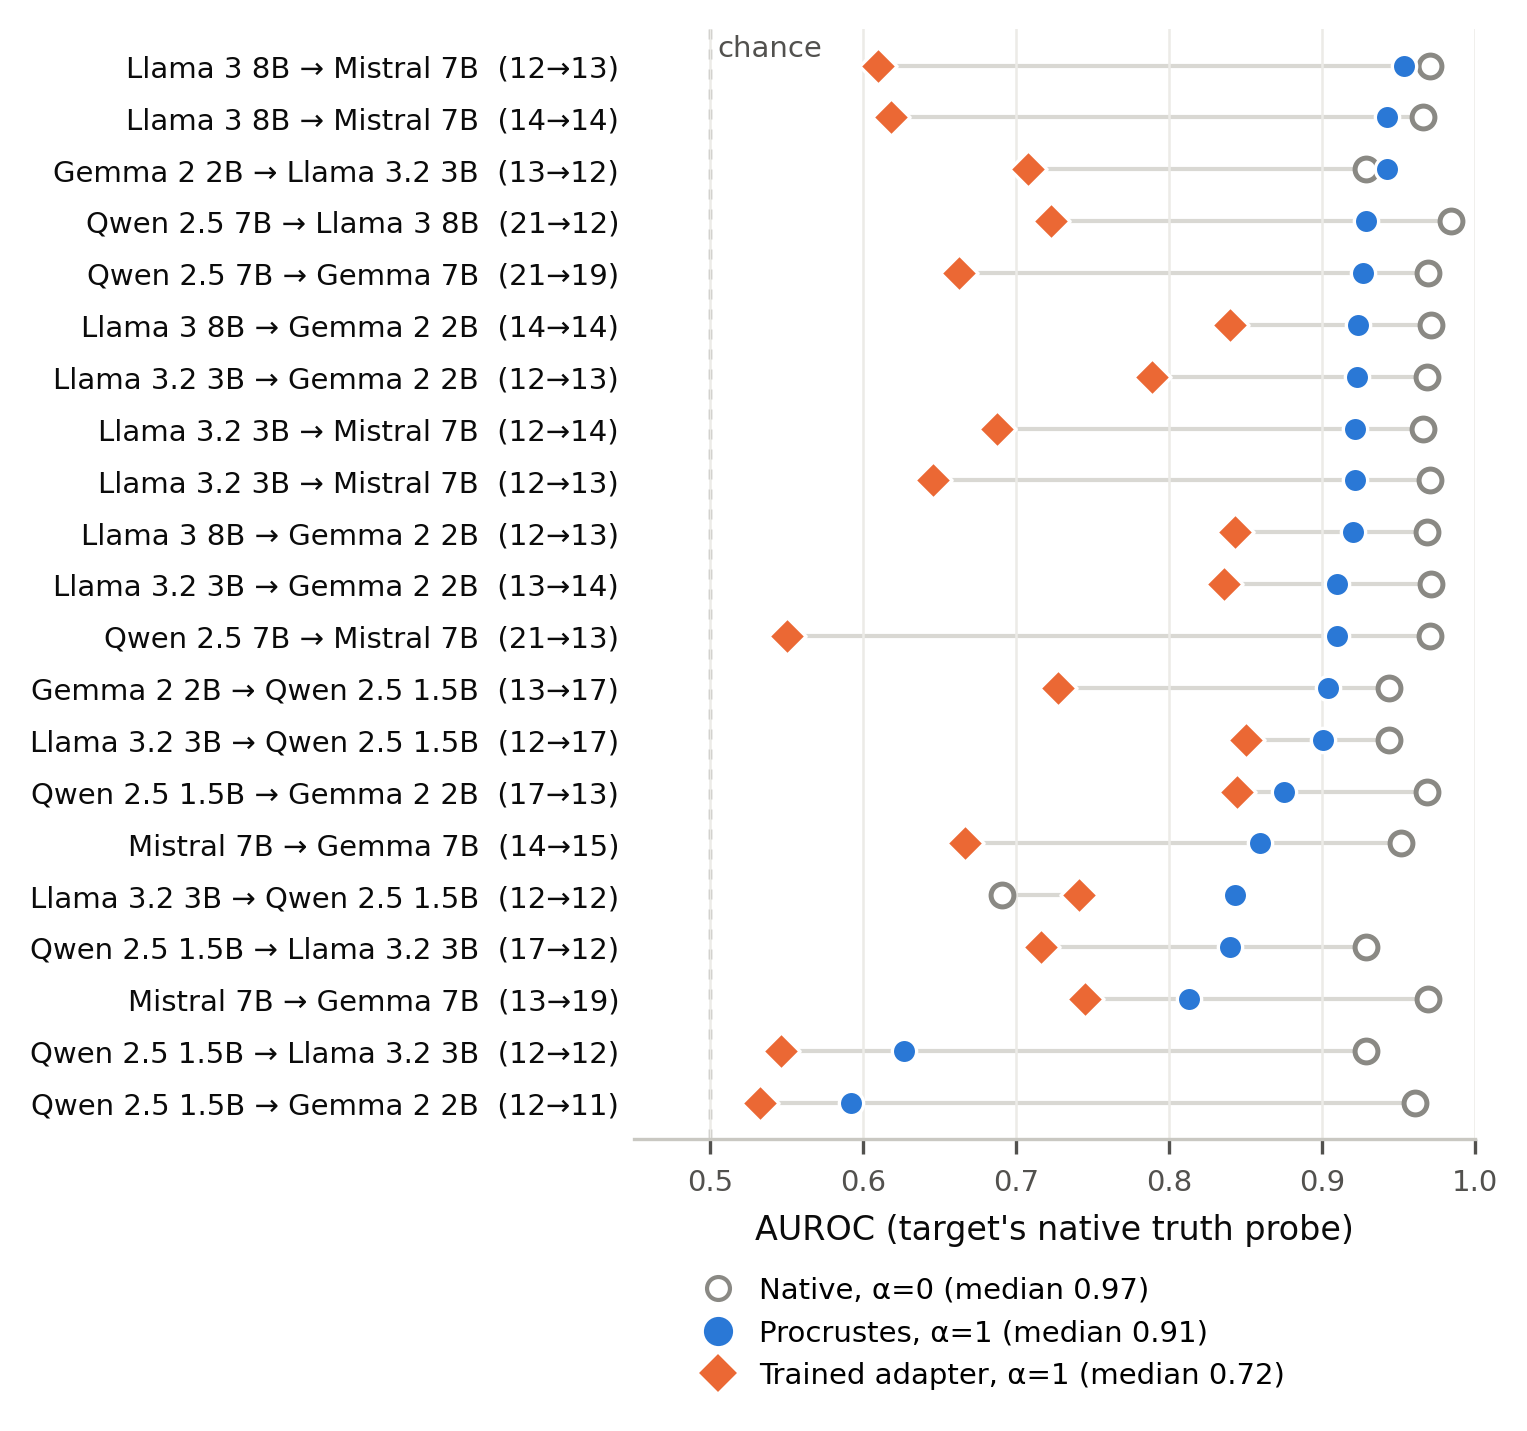

saved -> /content/alpha1_auroc_procrustes_vs_trained.pdf / .png


In [16]:
# --- figure + AUROC rank correlation ------------------------------------------
from scipy.stats import spearmanr
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import display, Image
from matplotlib.lines import Line2D

NAMES = {"gemma2-2b": "Gemma 2 2B", "gemma-7b": "Gemma 7B", "llama3-8b": "Llama 3 8B",
         "llama3_2-3b": "Llama 3.2 3B", "mistral-7b": "Mistral 7B",
         "qwen2_5-1_5b": "Qwen 2.5 1.5B", "qwen2_5-7b": "Qwen 2.5 7B"}
BLUE, ORANGE, GREY, INK, MUTED = "#2a78d6", "#eb6834", "#8a8984", "#0b0b0b", "#52514e"


def label(pid):
    try:
        src, tgt = pid.split("__")[0].split("_to_")
        (s, sl), (t, tl) = (x.rsplit("-instruct_l", 1) for x in (src, tgt))
    except ValueError:
        return pid
    return f"{NAMES.get(s, s)} → {NAMES.get(t, t)}  ({sl}→{tl})"


def plot(rows, out_stem):
    """rows: dicts with pair_id, native (=AUROC at alpha 0), procrustes, trained (AUROC at alpha 1)."""
    rows = sorted(rows, key=lambda r: r["procrustes"])
    fig, ax = plt.subplots(figsize=(5.2, 4.9))
    for i, r in enumerate(rows):
        ax.plot([r["trained"], r["native"]], [i, i], color="#d9d8d3", lw=1, zorder=1)
        ax.scatter(r["native"], i, s=30, facecolor="white", edgecolor=GREY, lw=1.2, zorder=3)
        ax.scatter(r["procrustes"], i, s=34, marker="o", color=BLUE, edgecolor="white", lw=0.8, zorder=4)
        ax.scatter(r["trained"], i, s=40, marker="D", color=ORANGE, edgecolor="white", lw=0.8, zorder=4)
    ax.axvline(0.5, color=GREY, lw=0.8, ls=(0, (3, 3)), zorder=0)
    ax.text(0.505, len(rows) - 0.4, "chance", fontsize=7, color=MUTED, va="top")
    ax.set_yticks(range(len(rows)), [label(r["pair_id"]) for r in rows], fontsize=7, color=INK)
    ax.set_xlim(0.45, 1.0)
    ax.set_ylim(-0.7, len(rows) - 0.3)
    ax.set_xlabel("AUROC (target's native truth probe)", fontsize=8, color=INK)
    ax.tick_params(axis="x", labelsize=7, colors=MUTED)
    ax.tick_params(axis="y", length=0)
    ax.grid(axis="x", color="#ecebe7", lw=0.6)
    for s in ("top", "right", "left"):
        ax.spines[s].set_visible(False)
    ax.spines["bottom"].set_color("#c9c8c2")
    med = lambda k: sorted(r[k] for r in rows)[len(rows) // 2]
    handles = [
        Line2D([], [], marker="o", ls="", mfc="white", mec=GREY, ms=5.5, label=f"Native, α=0 (median {med('native'):.2f})"),
        Line2D([], [], marker="o", ls="", color=BLUE, ms=6, label=f"Procrustes, α=1 (median {med('procrustes'):.2f})"),
        Line2D([], [], marker="D", ls="", color=ORANGE, ms=5.5, label=f"Trained adapter, α=1 (median {med('trained'):.2f})"),
    ]
    ax.legend(handles=handles, fontsize=7, frameon=False, loc="upper center",
              bbox_to_anchor=(0.42, -0.1), ncol=1, handletextpad=0.4)
    fig.tight_layout()
    for ext in ("pdf", "png"):
        fig.savefig(f"{out_stem}.{ext}", dpi=300, bbox_inches="tight")
    plt.close(fig)


fig_rows = [dict(pair_id=p, native=r["proc_auroc_a0"], procrustes=r["proc_auroc_a1"],
                 trained=r["trained_auroc_a1"]) for p, r in pdf.iterrows()]
rho, pval = spearmanr(pdf["trained_auroc_a1"], pdf["proc_auroc_a1"])
print(f"Spearman ρ between methods' AUROC at α=1: {rho:+.3f} (p={pval:.3f}), n={len(pdf)}")
print(f"Procrustes AUROC at α=1 higher than trained on {int((pdf.proc_auroc_a1 > pdf.trained_auroc_a1).sum())}/{len(pdf)}")
stem = OUT_PATH.parent / "alpha1_auroc_procrustes_vs_trained"
plot(fig_rows, str(stem))
display(Image(f"{stem}.png"))
print(f"saved -> {stem}.pdf / .png")

In [8]:
# --- save -------------------------------------------------------------------
out = {
    "population": POPULATION, "unique": UNIQUE, "duplicates": DUPLICATES,
    "j_definition": "(mean_T - mean_F)^2 / (var_T + var_F) on target-probe scores, ddof=0",
    "aggregates_n21": agg21, "aggregates_n22": agg22,
    "paper": {k: v[0] for k, v in PAPER.items()},
    "which_population_matches": check["which"].to_dict(),
    "per_trajectory": per.reset_index().to_dict(orient="records"),
    "median_curve_n21": curve.reset_index().to_dict(orient="records"),
    "procrustes_a1_n21": pdf.reset_index().to_dict(orient="records"),
    "results_revision": REVISION,
}
json.dump(out, open(OUT_PATH, "w"), indent=2, default=float)
print(f"saved -> {OUT_PATH}")

saved -> /content/sec42_recheck.json
